## A. Division of Labour
- **Sarah Malik (#40175868):** Data cleaning, hierarchical imputation strategy, `quantDDA` function implementation.
- **Vu Bao Minh Nguyen (#40236101):** EDA and research-question formulation, baseline decision tree model (supervised), time-series analysis (unsupervised), `vizDDA` visualization function.
- **Xia Zhu (#26866883):** Data retrieval (Kaggle API integration), dataset audit, column selection and reduction, overall layout cleanup.

## B. References
- Moosavi, S. (accessed 2026). *US Accidents (2016–2023).* Kaggle: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/data.

## Phase 1: Data acquisition, exploration, baseline analysis
Report format: Jupyter notebook with code, outputs, visualizations, markdown explanations, division of labour, and references.

Phase objectives:
- Dataset acquisition and exploration.
- Identification of data-quality issues.
- Establishment of baseline performance.
- Compatibility with subsequent tasks (i.e., suitability for supervised and unsupervised machine learning).

### Phase 1 Deliverables

1. **Data Retrieval (10):** Document sources; implement programmatic retrieval (SQL/API/scraping); handle challenges (rate limits, authentication); and store raw data.
2. **Wrangling/Cleaning (10):** Perform an initial audit (missing values, duplicates, outliers); build a reproducible pipeline; and use `quantDDA()` / `vizDDA()`.
3. **EDA (10):** Produce summary statistics and uni/bivariate visualizations, run correlation analysis, and formulate two research questions (one supervised, one unsupervised).
4. **Baseline Model (12):** Train a simple model (logistic/linear regression or decision tree) with a train/validation/test split (70%/15%/15%), evaluate with appropriate metrics, and discuss performance.
5. **Report (8):** Submit a Jupyter notebook with code, outputs, visualizations, markdown explanations, division of labour, and references.

### Initialization
Required Python libraries are installed.

Note: Polars is used because direct Pandas processing is too memory-intensive for this dataset. PySpark was considered, but setup complexity was higher and performance was still less efficient than Polars for this workflow.

In [ ]:
%pip install -q polars pyarrow kagglehub pandas matplotlib seaborn scipy scikit-learn graphviz

Required packages are imported.

In [ ]:
from pathlib import Path

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import graphviz
from sklearn.linear_model import LinearRegression

try:
    import kagglehub
except ImportError:
    kagglehub = None

The dataset is imported from Kaggle, and file availability is validated.

In [ ]:
# Define dataset source metadata.
file_name = "US_Accidents_March23.csv"
dataset_name = "sobhanmoosavi/us-accidents"

# Prefer a local dataset file when available.
local_candidates = [
    Path.cwd() / file_name,
    Path(file_name)
]
existing_local = next((p for p in local_candidates if p.exists()), None)

if existing_local is not None:
    file_path = str(existing_local)
    print(f"Using local dataset file: {file_path}")
elif kagglehub is not None:
    local_dataset_path = kagglehub.dataset_download(dataset_name)
    file_path = str(Path(local_dataset_path) / file_name)
    print(f"Dataset downloaded to: {local_dataset_path}")
    print(f"Attempting to load file: {file_path}")
else:
    raise FileNotFoundError(
        f"Could not find '{file_name}' locally and 'kagglehub' is not available. "
        "Place the CSV beside the notebook or install kagglehub."
    )

# Load the dataset with Polars LazyFrame and materialize it as a DataFrame.
lazy_df = pl.scan_csv(
    file_path,
    try_parse_dates=True,
    infer_schema_length=10000,
    low_memory=True
)

df = lazy_df.collect()
print("Polars DataFrame loaded successfully.")

Using Colab cache for faster access to the 'us-accidents' dataset.
Dataset downloaded to: /kaggle/input/us-accidents
Attempting to load file: /kaggle/input/us-accidents/US_Accidents_March23.csv
Polars DataFrame loaded successfully.


The schema is loaded to confirm that required variables are present.

In [ ]:
print("Schema:")
for col, dtype in df.schema.items():
    print(f"- {col}: {dtype}")

print("\nPreview:")
with pl.Config(tbl_cols=-1, tbl_width_chars=2000):
    print(df.head(5))

rows, cols = df.shape
print(f"\nDataset has {rows} rows and {cols} columns.")

Schema:
- ID: String
- Source: String
- Severity: Int64
- Start_Time: Datetime(time_unit='us', time_zone=None)
- End_Time: Datetime(time_unit='us', time_zone=None)
- Start_Lat: Float64
- Start_Lng: Float64
- End_Lat: String
- End_Lng: String
- Distance(mi): Float64
- Description: String
- Street: String
- City: String
- County: String
- State: String
- Zipcode: String
- Country: String
- Timezone: String
- Airport_Code: String
- Weather_Timestamp: Datetime(time_unit='us', time_zone=None)
- Temperature(F): Float64
- Wind_Chill(F): Float64
- Humidity(%): Float64
- Pressure(in): Float64
- Visibility(mi): Float64
- Wind_Direction: String
- Wind_Speed(mph): Float64
- Precipitation(in): Float64
- Weather_Condition: String
- Amenity: Boolean
- Bump: Boolean
- Crossing: Boolean
- Give_Way: Boolean
- Junction: Boolean
- No_Exit: Boolean
- Railway: Boolean
- Roundabout: Boolean
- Station: Boolean
- Stop: Boolean
- Traffic_Calming: Boolean
- Traffic_Signal: Boolean
- Turning_Loop: Boolean
- Sunri

The `quantDDA` function is defined for quantitative descriptive analysis of dataset variables.

In [ ]:
import polars.selectors as cs

def quantDDA(df: pl.DataFrame):
    """
    Perform Quantitative Descriptive Data Analysis on a Polars dataframe.
    """
    print("=" * 80)
    print("QUANTITATIVE DESCRIPTIVE DATA ANALYSIS (quantDDA)")
    print("=" * 80)

    total_rows, total_cols = df.shape
    all_cols = df.columns

    exclude_lower = {"description", "id"}
    exclude_cols = {c for c in all_cols if c.lower() in exclude_lower}
    analysis_cols = [c for c in all_cols if c not in exclude_cols]

    # Section 1: Dataset overview.
    print("\n1. DATASET OVERVIEW")
    print(f"   Number of Observations (Rows): {total_rows}")
    print(f"   Number of Variables (Columns): {total_cols}")
    print(f"   Total Data Points: {total_rows * total_cols}")

    # Section 2: Column-level profile.
    print("\n2. COLUMN INFORMATION")
    print(f"   {'Column':<20} {'Type':<12} {'Entries':<10} {'Unique':<10} {'Missing':<10} {'Missing %':<12}")
    print("   " + "-" * 80)

    null_counts = df.null_count().row(0, named=True)
    for col_name in analysis_cols:
        dtype = df.schema[col_name]
        missing = int(null_counts.get(col_name, 0))
        entries = total_rows - missing
        unique = df.select(pl.col(col_name).n_unique()).item()
        missing_pct = (missing / total_rows * 100) if total_rows else 0
        print(f"   {col_name:<20} {str(dtype):<12} {entries:<10} {unique:<10} {missing:<10} {missing_pct:<12.2f}")

    # Section 3: Numeric descriptive statistics.
    print("\n3. DESCRIPTIVE STATISTICS (NUMERIC COLUMNS)")
    numeric_cols = [c for c in df.select(cs.numeric()).columns if c in analysis_cols]

    if numeric_cols:
        for col_name in numeric_cols:
            print(f"\n   {col_name.upper()}")
            print("   " + "-" * 70)

            series = df.get_column(col_name)
            data = series.drop_nulls().to_numpy()

            if data.size == 0:
                print("   No valid data available for this column.")
                continue

            # Summarize record counts and missingness.
            print(f"   Observations:        {total_rows}")
            print(f"   Valid Entries:       {len(data)}")
            print(f"   Unique Values:       {series.n_unique()}")
            missing = total_rows - len(data)
            missing_pct = (missing / total_rows * 100) if total_rows else 0
            print(f"   Missing Entries:     {missing} ({missing_pct:.2f}%)")

            mean_val = float(series.mean())
            std_val = float(series.std())
            min_val = float(series.min())
            max_val = float(series.max())

            print(f"\n   Mean:                {mean_val:.4f}")
            print(f"   Std Deviation:       {std_val:.4f}")
            print(f"   Minimum:             {min_val:.4f}")
            print(f"   Maximum:             {max_val:.4f}")
            print(f"   Range:               {max_val - min_val:.4f}")

            q1 = float(series.quantile(0.25))
            q2 = float(series.quantile(0.50))
            q3 = float(series.quantile(0.75))
            print(f"\n   Q1 (25th percentile): {q1:.4f}")
            print(f"   Q2 (Median):          {q2:.4f}")
            print(f"   Q3 (75th percentile): {q3:.4f}")
            print(f"   IQR (Q3-Q1):          {q3 - q1:.4f}")

            # Compute mode candidates.
            value_counts = (
                df.select(pl.col(col_name)).drop_nulls()
                .group_by(col_name).len()
                .sort("len", descending=True)
            )
            if value_counts.height > 0:
                top_modes = value_counts.head(5).to_dicts()
                if len(top_modes) == 1:
                    print(f"   Mode:                 {top_modes[0][col_name]:.4f}")
                else:
                    mode_str = ", ".join([f"{row[col_name]:.4f}" for row in top_modes])
                    if value_counts.height > 5:
                        mode_str += f" ... ({value_counts.height} modes)"
                    print(f"   Modes:                {mode_str}")

            # Detect outliers using the IQR rule.
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = data[(data < lower_bound) | (data > upper_bound)]
            outlier_pct = (len(outliers) / len(data) * 100) if len(data) else 0
            print(f"\n   Outliers (IQR):       {len(outliers)} ({outlier_pct:.2f}%)")
            if len(outliers) > 0:
                print(f"   IQR Lower Bound:      {lower_bound:.4f}")
                print(f"   IQR Upper Bound:      {upper_bound:.4f}")

            # Compute extreme-value thresholds.
            bottom_1pct = float(series.quantile(0.01))
            top_1pct = float(series.quantile(0.99))
            extreme_low = data[data <= bottom_1pct]
            extreme_high = data[data >= top_1pct]
            print(f"\n   Bottom 1% Threshold:  {bottom_1pct:.4f} ({len(extreme_low)} values)")
            print(f"   Top 1% Threshold:     {top_1pct:.4f} ({len(extreme_high)} values)")

            # Characterize distribution shape.
            skewness = float(stats.skew(data))
            kurtosis_val = float(stats.kurtosis(data))
            print(f"\n   Skewness:             {skewness:.4f}", end="")
            if skewness > 1:
                print(" (highly right-skewed)")
            elif skewness > 0.5:
                print(" (moderately right-skewed)")
            elif skewness < -1:
                print(" (highly left-skewed)")
            elif skewness < -0.5:
                print(" (moderately left-skewed)")
            else:
                print(" (approximately symmetric)")

            print(f"   Kurtosis:             {kurtosis_val:.4f}", end="")
            if kurtosis_val > 3:
                print(" (heavy-tailed)")
            elif kurtosis_val < -1:
                print(" (light-tailed)")
            else:
                print(" (normal-like)")
    else:
        print("   No numeric columns found in dataframe.")

    # Section 4: Categorical summary.
    print("\n\n4. CATEGORICAL COLUMN SUMMARY")
    categorical_cols = [c for c in df.select(cs.string()).columns if c in analysis_cols]

    if categorical_cols:
        for col_name in categorical_cols:
            print(f"\n   {col_name.upper()}")
            print("   " + "-" * 70)

            series = df.get_column(col_name)
            valid = series.drop_nulls()

            print(f"   Observations:        {total_rows}")
            print(f"   Valid Entries:       {valid.len()}")
            print(f"   Unique Values:       {series.n_unique()}")
            missing = total_rows - valid.len()
            missing_pct = (missing / total_rows * 100) if total_rows else 0
            print(f"   Missing Entries:     {missing} ({missing_pct:.2f}%)")

            if valid.len() > 0:
                value_counts = (
                    df.select(pl.col(col_name)).drop_nulls()
                    .group_by(col_name).len()
                    .sort("len", descending=True)
                )
                if value_counts.height > 0:
                    top_row = value_counts.row(0, named=True)
                    print(f"   Mode:                {top_row[col_name]} ({top_row['len']} occurrences)")

                print("\n   Top 5 Most Frequent Values:")
                top_rows = value_counts.head(5).to_dicts()
                valid_len = valid.len()
                for row in top_rows:
                    count = row.get("len", 0)
                    pct = (count / valid_len * 100) if valid_len else 0
                    print(f"      {row[col_name]}: {count} ({pct:.2f}%)")
    else:
        print("   No categorical columns found in dataframe.")

    print("\n" + "=" * 80 + "\n")

The `vizDDA` function is defined for visual descriptive analysis of dataset variables.

The function generates histograms, boxplots, and a correlation heatmap.

In [ ]:
def vizDDA(df: pl.DataFrame, max_numeric_features: int = 12, max_categorical_features: int = 8):
    """
    Args:
        df: Polars DataFrame to analyze
        max_numeric_features: Maximum number of numeric features to visualize
        max_categorical_features: Maximum number of categorical features in pairs
    """
    print("=" * 80)
    print("VISUAL DESCRIPTIVE DATA ANALYSIS (vizDDA)")
    print("=" * 80)

    total_rows, total_cols = df.shape

    # Identify numeric and categorical features.
    numeric_cols = [c for c in df.select(cs.numeric()).columns if c.lower() not in {"description", "id"}]
    categorical_cols = [c for c in df.select(cs.string()).columns if c.lower() not in {"description", "id"}]

    print(f"\nIdentified {len(numeric_cols)} numeric and {len(categorical_cols)} categorical columns.\n")

    # =========================================================================
    # Section 1: Histograms for numeric features.
    # =========================================================================
    if numeric_cols:
        print(f"1. HISTOGRAMS FOR NUMERIC FEATURES")
        print("-" * 80)

        # Limit plotting to the configured number of features.
        cols_to_plot = numeric_cols[:max_numeric_features]

        # Build a near-square subplot grid.
        n_cols = min(3, len(cols_to_plot))
        n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

        # Flatten axes for consistent iteration.
        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1 or n_cols == 1:
            axes = axes.reshape(-1, 1) if n_cols == 1 else axes.reshape(1, -1)

        axes = axes.flatten()

        for idx, col in enumerate(cols_to_plot):
            ax = axes[idx]
            data = df.get_column(col).drop_nulls().to_numpy()

            ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
            ax.set_title(f'{col}\n(n={len(data)}, μ={data.mean():.2f}, σ={data.std():.2f})', fontsize=10, fontweight='bold')
            ax.set_xlabel('Value', fontsize=9)
            ax.set_ylabel('Frequency', fontsize=9)
            ax.grid(True, alpha=0.3)

        # Hide any unused subplot axes.
        for idx in range(len(cols_to_plot), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.savefig('vizDDA_histograms.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Plotted histograms for {len(cols_to_plot)} numeric features.\n")
    else:
        print("   No numeric columns found.\n")

    # =========================================================================
    # Section 2: Boxplots for outlier inspection.
    # =========================================================================
    if numeric_cols:
        print(f"2. BOXPLOTS FOR OUTLIER VISUALIZATION")
        print("-" * 80)

        cols_to_plot = numeric_cols[:max_numeric_features]
        n_cols = min(3, len(cols_to_plot))
        n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1 or n_cols == 1:
            axes = axes.reshape(-1, 1) if n_cols == 1 else axes.reshape(1, -1)

        axes = axes.flatten()

        for idx, col in enumerate(cols_to_plot):
            ax = axes[idx]
            data = df.get_column(col).drop_nulls().to_numpy()

            # Draw a boxplot for the current feature.
            bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5)
            bp['boxes'][0].set_facecolor('lightblue')
            bp['boxes'][0].set_alpha(0.7)

            # Calculate IQR bounds and outliers.
            q1 = np.percentile(data, 25)
            q3 = np.percentile(data, 75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = data[(data < lower_bound) | (data > upper_bound)]

            ax.set_title(f'{col}\nOutliers: {len(outliers)} ({100*len(outliers)/len(data):.1f}%)',
                        fontsize=10, fontweight='bold')
            ax.set_ylabel('Value', fontsize=9)
            ax.grid(True, alpha=0.3, axis='y')

            # Annotate median and IQR values.
            summary_text = f'Median: {np.median(data):.2f}\nIQR: {iqr:.2f}'
            ax.text(1.15, np.median(data), summary_text, fontsize=8, va='center')

        # Hide any unused subplot axes.
        for idx in range(len(cols_to_plot), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.savefig('vizDDA_boxplots.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Plotted boxplots for {len(cols_to_plot)} numeric features.\n")
    else:
        print("   No numeric columns found.\n")

    # =========================================================================
    # Section 3: Correlation heatmap.
    # =========================================================================
    if len(numeric_cols) >= 2:
        print(f"3. CORRELATION HEATMAP")
        print("-" * 80)

        # Convert numeric columns to pandas for correlation computation.
        df_numeric = df.select(numeric_cols).to_pandas()

        # Compute the correlation matrix.
        corr_matrix = df_numeric.corr()

        # Render the correlation heatmap.
        fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) // 2), max(8, len(numeric_cols) // 2)))

        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax,
                   vmin=-1, vmax=1)

        ax.set_title(f'Correlation Matrix: {len(numeric_cols)} Numeric Features',
                    fontsize=12, fontweight='bold', pad=20)

        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.savefig('vizDDA_correlation_heatmap.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Report correlation summary statistics.
        print(f"   {len(numeric_cols)} numeric features analyzed.")
        print(f"\n   Strongest Correlations (|r| > 0.5):")

        # Identify strong pairwise correlations (excluding diagonal values).
        strong_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.5:
                    strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

        if strong_corr:
            strong_corr.sort(key=lambda x: abs(x[2]), reverse=True)
            for col1, col2, corr_val in strong_corr[:10]:  # Report the top 10 strongest pairs.
                print(f"      {col1} ↔ {col2}: {corr_val:+.4f}")
        else:
            print("      No strong correlations (|r| > 0.5) found.")

        print()
    else:
        print("   Need at least 2 numeric columns for correlation analysis.\n")

    print("=" * 80 + "\n")


An initial `quantDDA` assessment is performed on the full dataset.

In [ ]:
print("Quantitative Data Analysis using Polars")
quantDDA(df)

Quantitative Data Analysis using Polars
QUANTITATIVE DESCRIPTIVE DATA ANALYSIS (quantDDA)

1. DATASET OVERVIEW
   Number of Observations (Rows): 7728394
   Number of Variables (Columns): 46
   Total Data Points: 355506124

2. COLUMN INFORMATION
   Column               Type         Entries    Unique     Missing    Missing %   
   --------------------------------------------------------------------------------
   Source               String       7728394    3          0          0.00        
   Severity             Int64        7728394    4          0          0.00        
   Start_Time           Datetime(time_unit='us', time_zone=None) 7728394    5801064    0          0.00        
   End_Time             Datetime(time_unit='us', time_zone=None) 7728394    6463024    0          0.00        
   Start_Lat            Float64      7728394    2449172    0          0.00        
   Start_Lng            Float64      7728394    2493905    0          0.00        
   End_Lat              String    

### Missing-Value Assessment and Handling

#### 1) High-missingness location endpoints
The largest missing-value counts are in **`End_Lat`** and **`End_Lng`**.
Because many accident records represent single-point events, **`Start_Lat`** and **`Start_Lng`** are sufficient for location analysis in this phase.
Therefore, **`End_Lat`** and **`End_Lng`** are dropped.

#### 2) Weather-related missing values
A major missing-value group includes weather fields, notably **`Wind_Chill(F)`** and several numeric weather measurements.

- **`Wind_Chill(F)`** is dropped in this phase (partly redundant with other weather signals and excluded by design).
- The following weather variables are retained and imputed for modeling:
  - **`Precipitation(in)`**.
  - **`Temperature(F)`**.
  - **`Humidity(%)`**.
  - **`Pressure(in)`**.
  - **`Visibility(mi)`**.
  - **`Wind_Speed(mph)`**.

For each retained numeric weather variable above, missing values are imputed using hierarchical median imputation in this order:

1. Median by **(`Weather_Condition`, `City`)**.
2. Median by **(`Weather_Condition`, `County`)**.
3. Median by **(`Weather_Condition`, `State`)**.
4. Median by **`City`**.
5. Median by **`County`**.
6. Median by **`State`**.

#### 3) Note on `Weather_Condition` missingness
Missing **`Weather_Condition`** values are kept as null (not converted into a literal category).
If condition-based groups are unavailable, imputation falls back to broader geographic levels (City/County/State).

#### 4) `Timezone` missing values
`Timezone` is retained and imputed using a location-based fallback.

Imputation order:
1. Fill from the most common `Timezone` within the same **`City`** *(cities should have the same time zones)*.
2. If still missing, fill from the most common `Timezone` within the same **`County`**, then **`State`** *(only a small number of states span multiple time zones)*.

If both City- and State-level lookups are unavailable, the value remains null for later handling.
This preserves geographic consistency while avoiding arbitrary default timezone assignments.

#### 5) Additional missing fields
- **`Zipcode`** has missing values, but is lower priority for current research questions because street/city/county/state are available.
- Other weather variables with missingness can be imputed later using the same hierarchical strategy.
- Missing values in **`City`** and **`State`** are kept as null in this phase. These fields are not primary targets for the current research questions, and deferring imputation avoids introducing potentially incorrect geographic assumptions.
---

### Variables Excluded in This Phase

- **Location endpoints dropped**: `End_Lat`, `End_Lng`.
- **Phase-1 exclusions**: `Weather_Timestamp`, `Wind_Chill(F)`, `Airport_Code`, `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, `Astronomical_Twilight`.
- **Dropped if constant**: `Country`, `Turning_Loop`.

In [ ]:
# ============================================================
# Feature pruning and hierarchical imputation.
# ============================================================

# Remove endpoint coordinates that are not needed for point-event records.
drop_location_endpoints = ["End_Lat", "End_Lng"]

# Define Phase 1 exclusions to reduce redundancy and scope.
drop_phase1_exclusions = [
    "Weather_Timestamp",   # Overlaps with accident time fields.
    "Wind_Chill(F)",       # Overlaps with other weather metrics.
    "Wind_Direction",      # Optional detail deferred in this phase.
    "Airport_Code",        # Not required for current objectives.
    "Sunrise_Sunset",      # Twilight/daylight variants are excluded.
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
    "Zipcode",             # City/county/state fields are already retained.
]

# Drop these columns only if they are constant in the current data.
drop_if_constant = ["Country", "Turning_Loop"]

# Work on a copy of the original DataFrame.
df_reduced = df.clone()

# Keep only configured drop candidates that exist in the data.
candidate_drop = drop_location_endpoints + drop_phase1_exclusions
existing_candidate_drop = [c for c in candidate_drop if c in df_reduced.columns]

# Evaluate constant-column candidates by uniqueness.
constant_dropped = []
constant_not_dropped = []
for c in drop_if_constant:
    if c in df_reduced.columns:
        nunique = df_reduced.select(pl.col(c).n_unique()).item()
        if nunique <= 1:
            constant_dropped.append(c)
        else:
            constant_not_dropped.append(c)

# Build the final column-drop list.
final_drop_cols = existing_candidate_drop + constant_dropped

# Track configured columns that are missing from the DataFrame.
missing_columns = [c for c in (candidate_drop + drop_if_constant) if c not in df_reduced.columns]

# Apply column removal.
df_reduced = df_reduced.drop(final_drop_cols)

# Report pruning summary.
print(f"Dropped {len(final_drop_cols)} columns: {final_drop_cols}")
if constant_not_dropped:
    print(f"Kept (not constant): {constant_not_dropped}")
if missing_columns:
    print(f"Skipped (not found): {missing_columns}")

rows, cols = df_reduced.shape
print(f"Updated dataset shape: {rows} rows x {cols} columns")

# ------------------------------------------------------------
# Hierarchical imputation for numeric weather fields (median).
# ------------------------------------------------------------
# Apply fallback groups from specific to broad levels.
# `Weather_Condition` itself is not imputed here.

weather_col = "Weather_Condition"
city_col = "City"
county_col = "County"
state_col = "State"

groupings = [
    [weather_col, city_col],
    [weather_col, county_col],
    [weather_col, state_col],
    [city_col],
    [county_col],
    [state_col],
]

numeric_impute_cols = [
    "Precipitation(in)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
]

def _fill_numeric_hierarchical(df_in: pl.DataFrame, col_name: str, group_levels: list[list[str]]) -> pl.DataFrame:
    """Fill nulls in one numeric column using hierarchical group medians."""
    df_out = df_in
    temp_cols = []

    # Build median lookup tables for each grouping level.
    for i, g in enumerate(group_levels):
        temp_col = f"__fill_{col_name}_{i}"
        lookup = (
            df_out
            .filter(pl.col(col_name).is_not_null())
            .group_by(g)
            .agg(pl.col(col_name).median().alias(temp_col))
        )
        df_out = df_out.join(lookup, on=g, how="left")
        temp_cols.append(temp_col)

    # Coalesce original values with hierarchical median fallbacks.
    df_out = df_out.with_columns(
        pl.coalesce([pl.col(col_name)] + [pl.col(c) for c in temp_cols]).alias(col_name)
    ).drop(temp_cols)

    return df_out

# Validate required grouping columns.
required_group_cols = [weather_col, city_col, county_col, state_col]
missing_group_cols = [c for c in required_group_cols if c not in df_reduced.columns]

if missing_group_cols:
    print(f"Skipped hierarchical imputation; missing grouping columns: {missing_group_cols}")
else:
    # Impute each numeric target column and report fill counts.
    for col in numeric_impute_cols:
        if col not in df_reduced.columns:
            print(f"Skipped {col}: column not found")
            continue

        before = df_reduced.select(pl.col(col).is_null().sum()).item()
        df_reduced = _fill_numeric_hierarchical(df_reduced, col, groupings)
        after = df_reduced.select(pl.col(col).is_null().sum()).item()
        print(f"{col}: filled {before - after}, remaining missing {after}")

# ------------------------------------------------------------
# Hierarchical imputation for `Timezone` (mode).
# ------------------------------------------------------------
# Fill null `Timezone` values using geographic mode fallback.

timezone_col = "Timezone"
timezone_groupings = [
    [city_col, state_col],
    [county_col, state_col],
    [state_col],
]

def _fill_categorical_hierarchical_mode(
    df_in: pl.DataFrame, col_name: str, group_levels: list[list[str]]
) -> pl.DataFrame:
    """Fill null categorical values using hierarchical group-wise mode."""
    df_out = df_in
    temp_cols = []

    for i, g in enumerate(group_levels):
        temp_col = f"__fill_{col_name}_{i}"

        lookup = (
            df_out
            .filter(pl.col(col_name).is_not_null())
            .group_by(g + [col_name])
            .agg(pl.len().alias("__n"))
            .sort(by=g + ["__n", col_name], descending=[False] * len(g) + [True, False])
            .unique(subset=g, keep="first")
            .select(g + [pl.col(col_name).alias(temp_col)])
        )

        df_out = df_out.join(lookup, on=g, how="left")
        temp_cols.append(temp_col)

    df_out = df_out.with_columns(
        pl.coalesce([pl.col(col_name)] + [pl.col(c) for c in temp_cols]).alias(col_name)
    ).drop(temp_cols)

    return df_out

if timezone_col not in df_reduced.columns:
    print(f"Skipped {timezone_col} imputation: column not found")
else:
    valid_timezone_groupings = [g for g in timezone_groupings if all(c in df_reduced.columns for c in g)]

    if not valid_timezone_groupings:
        print(f"Skipped {timezone_col} imputation: required grouping columns not found")
    else:
        before_tz = df_reduced.select(pl.col(timezone_col).is_null().sum()).item()
        df_reduced = _fill_categorical_hierarchical_mode(df_reduced, timezone_col, valid_timezone_groupings)
        after_tz = df_reduced.select(pl.col(timezone_col).is_null().sum()).item()
        print(f"{timezone_col}: filled {before_tz - after_tz}, remaining missing {after_tz}")


Dropped 13 columns: ['End_Lat', 'End_Lng', 'Weather_Timestamp', 'Wind_Chill(F)', 'Wind_Direction', 'Airport_Code', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Zipcode', 'Country', 'Turning_Loop']
Updated dataset shape: 7728394 rows x 33 columns
Precipitation(in): filled 2203586, remaining missing 0
Temperature(F): filled 163853, remaining missing 0
Humidity(%): filled 174144, remaining missing 0
Pressure(in): filled 140679, remaining missing 0
Visibility(mi): filled 177098, remaining missing 0
Wind_Speed(mph): filled 571233, remaining missing 0
Timezone: filled 7808, remaining missing 0


`quantDDA` is run again on the reduced dataset.

In [ ]:
quantDDA(df_reduced)

QUANTITATIVE DESCRIPTIVE DATA ANALYSIS (quantDDA)

1. DATASET OVERVIEW
   Number of Observations (Rows): 7728394
   Number of Variables (Columns): 33
   Total Data Points: 255037002

2. COLUMN INFORMATION
   Column               Type         Entries    Unique     Missing    Missing %   
   --------------------------------------------------------------------------------
   Source               String       7728394    3          0          0.00        
   Severity             Int64        7728394    4          0          0.00        
   Start_Time           Datetime(time_unit='us', time_zone=None) 7728394    5801064    0          0.00        
   End_Time             Datetime(time_unit='us', time_zone=None) 7728394    6463024    0          0.00        
   Start_Lat            Float64      7728394    2449172    0          0.00        
   Start_Lng            Float64      7728394    2493905    0          0.00        
   Distance(mi)         Float64      7728394    22382      0          0.00

`vizDDA` is applied to the reduced, cleaned dataset to visualize distributions, outliers, and correlations.

VISUAL DESCRIPTIVE DATA ANALYSIS (vizDDA)

Identified 10 numeric and 7 categorical columns.

1. HISTOGRAMS FOR NUMERIC FEATURES
--------------------------------------------------------------------------------


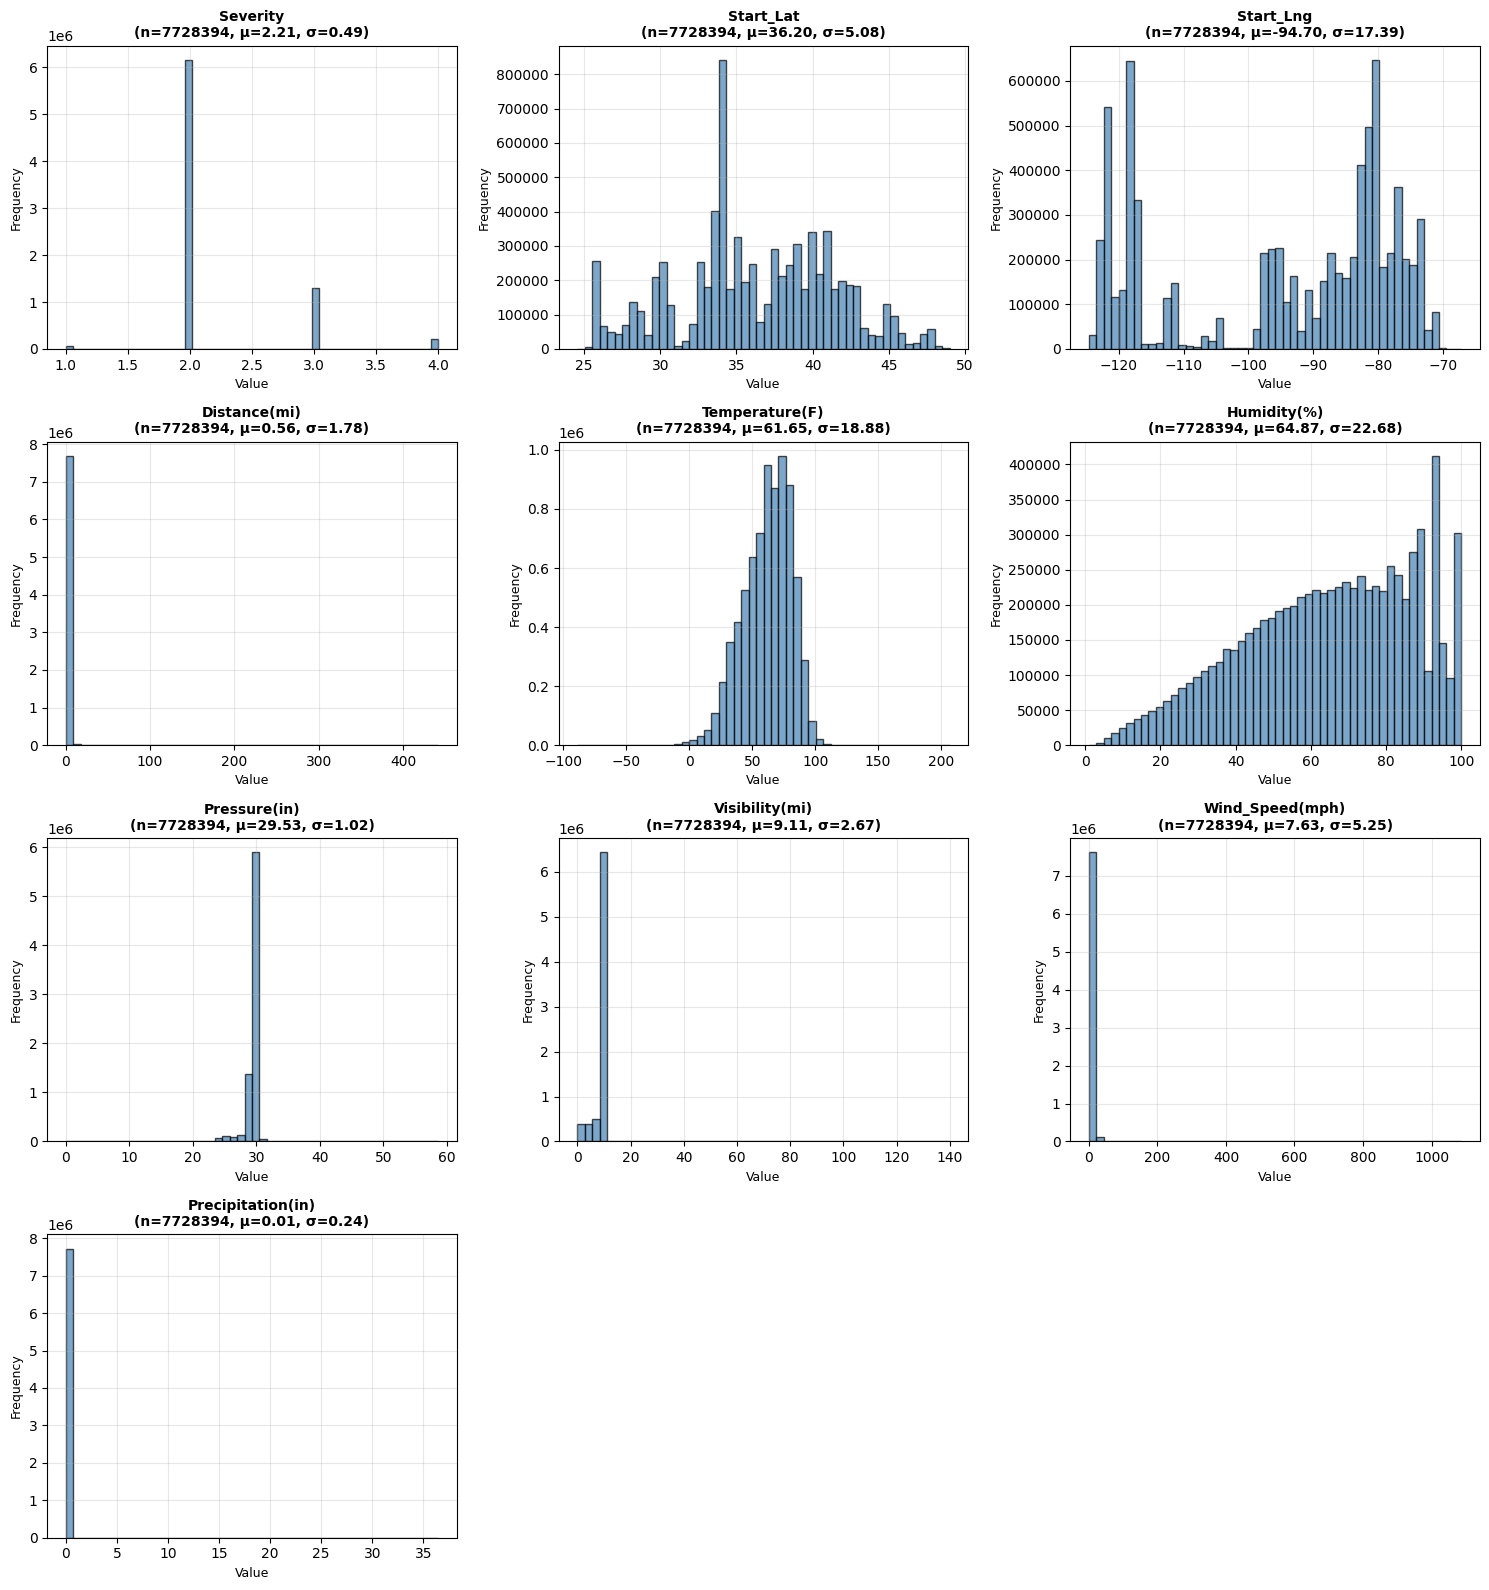

✓ Plotted histograms for 10 numeric features.

2. BOXPLOTS FOR OUTLIER VISUALIZATION
--------------------------------------------------------------------------------


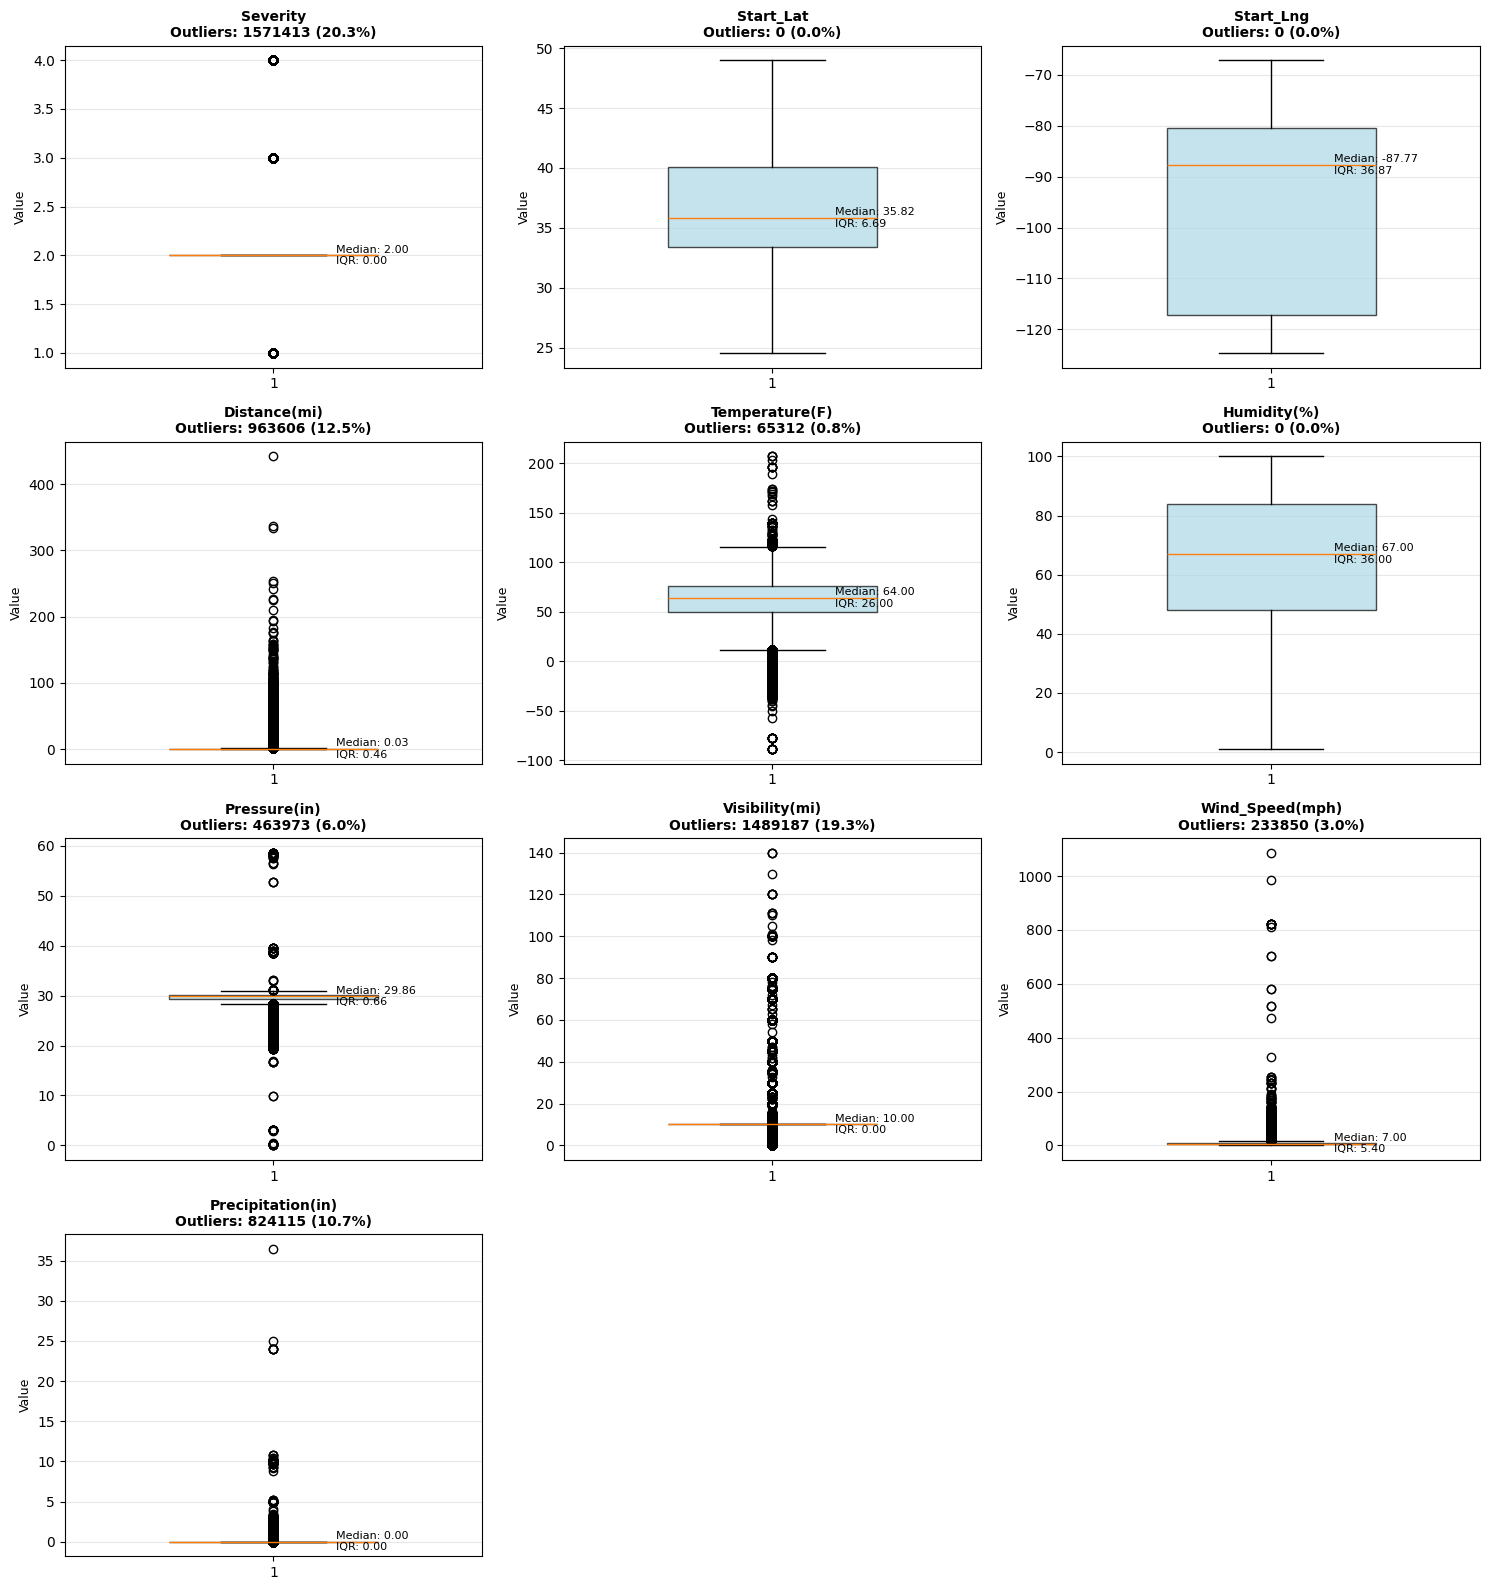

✓ Plotted boxplots for 10 numeric features.

3. CORRELATION HEATMAP
--------------------------------------------------------------------------------


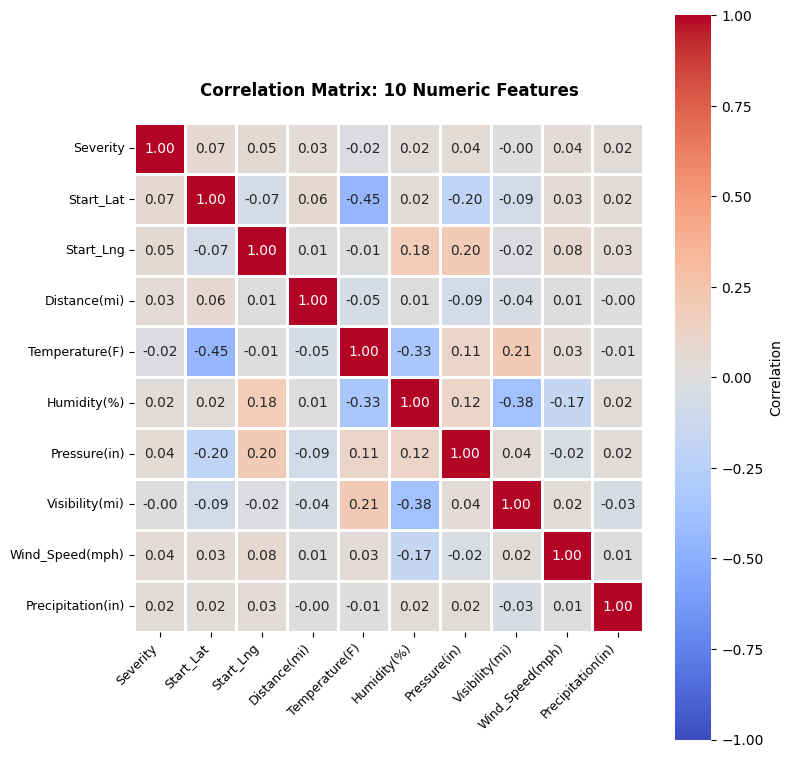

   10 numeric features analyzed.

   Strongest Correlations (|r| > 0.5):
      No strong correlations (|r| > 0.5) found.




In [ ]:
vizDDA(df_reduced)

#### Key Findings from `vizDDA` Analysis

**1. Distribution patterns**
- **Severity:** Highly imbalanced; most accidents are severity level 2 (80.5%), with relatively few level 4 accidents.
- **Precipitation:** Extremely right-skewed; most accidents occur in dry conditions (μ = 0.01 in).
- **Visibility:** Bimodal; most accidents occur in clear weather (≥10 mi) or very poor visibility (<1 mi).
- **Temperature:** Approximately normal (μ = 61.65°F), reflecting diverse climate conditions.
- **Distance:** Right-skewed; accident durations cluster near 0, indicating many brief incidents.
- **Geographic features:** `Start_Lat`/`Start_Lng` show clustering consistent with population density.

**2. Outlier detection (IQR method)**
- **Severity:** 20.3% outliers (level 4 severe accidents).
- **Distance:** 12.5% outliers (longest road blockages, >175 miles).
- **Visibility:** 19.3% outliers (extreme poor/excellent conditions).
- **Precipitation:** 10.7% outliers (heavy rainfall events).
- **Temperature:** 0.8% outliers (extreme hot/cold values).
- **Pressure:** 6.0% outliers (unusual atmospheric conditions).

**3. Correlation analysis**
- No strong correlations (|r| > 0.5) between feature pairs.
- Moderate negative correlations (|r| ≈ 0.30 to 0.45):
  - Temperature ↔ Humidity: -0.33 (typical inverse relationship).
  - Start_Lat ↔ Temperature: -0.45 (northern regions are colder).
  - Humidity ↔ Visibility: -0.38 (moisture reduces visibility).
- Weak relationship between weather and severity (r = 0.02 to 0.05).
- Weather features appear relatively independent, suggesting limited multicollinearity concerns for baseline modeling.

## Supervised Learning Research Question: How much does weather influence accident severity?

### Phase 1 Scope
- Temporarily exclude categorical and datetime features (e.g., `Weather_Condition`, `Start_Time`).
- Focus on numeric weather features for baseline modeling.

These excluded features will be incorporated in later phases.

#### 1. Convert `Severity` to Binary and Filter Target Columns

Note: `Severity` is an integer scale from 1 to 4.

We group outcomes into **LOW** severity (1, 2) and **HIGH** severity (3, 4).

In [ ]:
# Convert `Severity` to a binary target.
# Mapping: Severity 1/2 -> LOW (0), Severity 3/4 -> HIGH (1).

df_tmp = df_reduced.with_columns(pl.col("Severity")
                                .replace({1: 0, 2: 0, 3: 1, 4: 1}) )

# Select target and baseline weather predictors.
df_tmp = df_tmp.select( ["Severity", "Temperature(F)", "Visibility(mi)", "Wind_Speed(mph)"] )
df_tmp.head(8)

Severity,Temperature(F),Visibility(mi),Wind_Speed(mph)
i64,f64,f64,f64
1,36.9,10.0,9.0
0,37.9,10.0,8.0
0,36.0,10.0,3.5
1,35.1,9.0,4.6
0,36.0,6.0,3.5
1,37.9,7.0,3.5
0,34.0,7.0,3.5
1,34.0,7.0,3.5


#### 3. Baseline Decision Tree

Since selected columns were imputed with ranked median values, we can proceed with a baseline decision tree.

##### 3.1 Convert Polars DataFrame to Pandas DataFrame

In [ ]:
# Convert the working Polars DataFrame to pandas for sklearn.
df_tmp_to_pd = df_tmp.to_pandas()

##### 3.2 Split Data into Train/Validation/Test

In [ ]:
# Split data into train, validation, and test sets.
X = df_tmp_to_pd[["Temperature(F)", "Visibility(mi)", "Wind_Speed(mph)"]]
y = df_tmp_to_pd["Severity"]


# First split: 70% train and 30% holdout (to be split into validation/test).
X_train, X_valtest, y_train, y_valtest = train_test_split(
                                            X, y,
                                            test_size=0.3, random_state=42,
                                            stratify=y)

# Second split: divide holdout equally into validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
                                            X_valtest, y_valtest,
                                            test_size=0.5, random_state=42,
                                            stratify=y_valtest)

##### 3.3 Train the Tree and Predict `y` (Severity Class)

In [ ]:
# Train the decision tree and predict on the test set.
dt = tree.DecisionTreeClassifier(criterion="gini", class_weight="balanced", max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Generate test predictions.
y_pred = dt.predict(X_test)

##### 3.4 Compute Evaluation Metrics (F1, Recall, Precision, Accuracy)

In [ ]:
# Compute evaluation metrics: F1, recall, precision, and accuracy.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("Accuracy: {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall: {:.4f}".format(recall))
print("F1: {:.4f}".format(f1))

Accuracy: 0.4495
Precision: 0.2298
Recall: 0.7776
F1: 0.3547


##### 3.5 Visualize the Tree

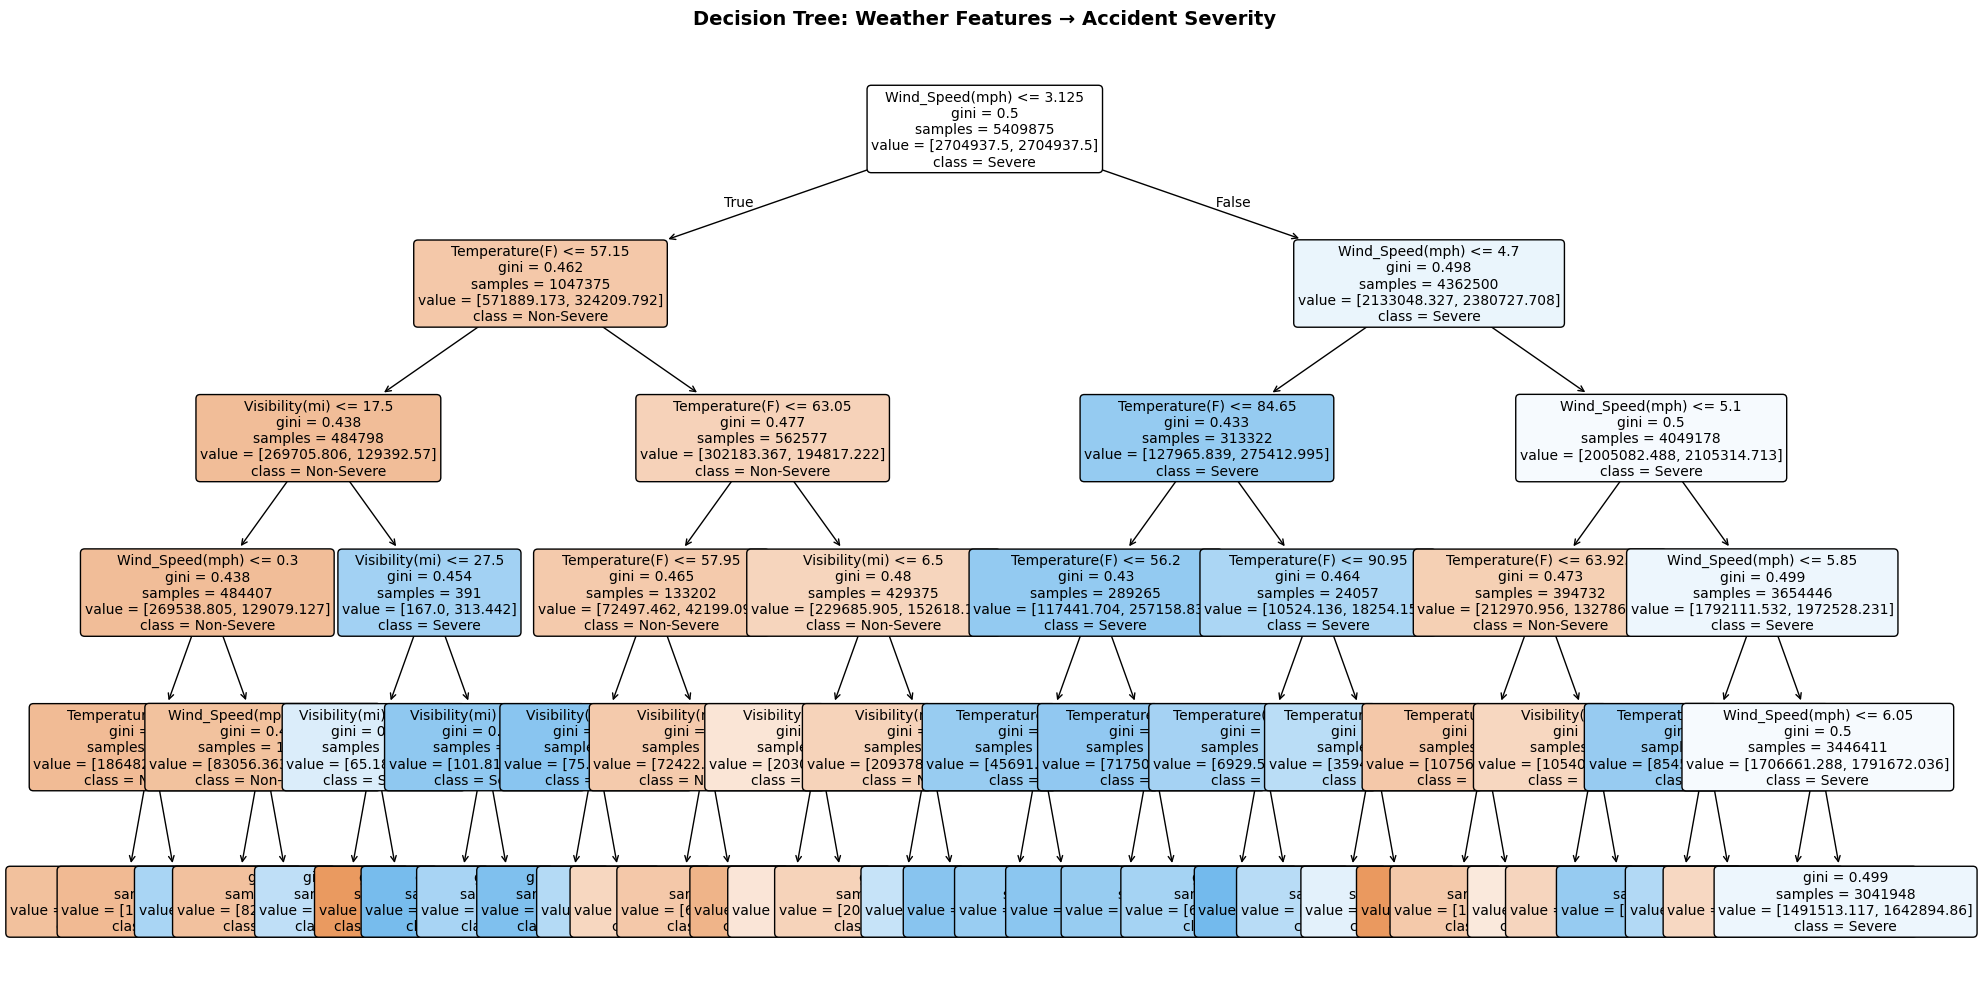


Decision Tree Depth: 5
Number of Leaves: 32
Feature Importances: {'Temperature(F)': np.float64(0.03142258987218317), 'Visibility(mi)': np.float64(0.004679797466470483), 'Wind_Speed(mph)': np.float64(0.9638976126613463)}


In [ ]:
# Visualize the trained decision tree.
# Use Matplotlib rendering to avoid external Graphviz runtime dependency.
fig, ax = plt.subplots(figsize=(20, 10))
tree.plot_tree(dt,
              feature_names=["Temperature(F)", "Visibility(mi)", "Wind_Speed(mph)"],
              class_names=["Non-Severe", "Severe"],
              filled=True,
              rounded=True,
              fontsize=10,
              ax=ax)
plt.title("Decision Tree: Weather Features → Accident Severity", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('SeverityPredictionTree.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nDecision Tree Depth: {dt.get_depth()}")
print(f"Number of Leaves: {dt.get_n_leaves()}")
print(f"Feature Importances: {dict(zip(['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)'], dt.feature_importances_))}")

#### 4. Performance Discussion

Key observations:

- Out of 7,728,394 observations, 80.54% are non-severe, indicating strong class imbalance.
- This imbalance contributes to low precision despite improved recall.
- If `class_weight="balanced"` is removed, accuracy increases but minority-class metrics can collapse toward 0.

In [ ]:
df_tmp["Severity"].value_counts()

Severity,count
i64,u32
1,1504047
0,6224347


## Unsupervised Learning Research Question
Research question: Are there natural clusters of accident scenarios based on environmental and road conditions?

### Exploratory Time–Severity Check
Supporting question: Are there patterns between accident time and severity?

Model used: Linear regression.

1. `X` is defined as accident hour (0–23), and `y` is defined as severity score.
2. A scatterplot of `X` vs. `y` is generated.
3. A best-fit line is estimated and plotted.

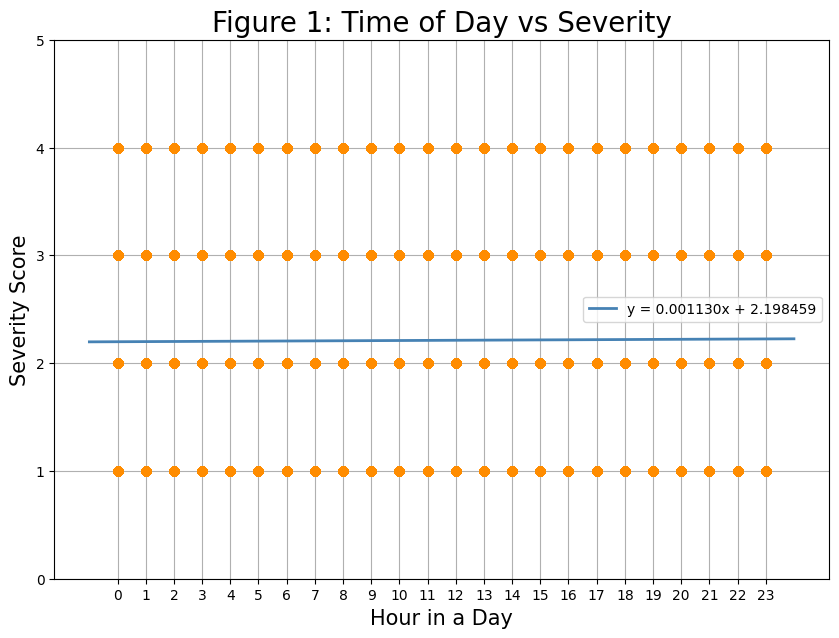

In [ ]:
plt.figure(figsize=(10, 7))

# Define variables for time-versus-severity analysis.
X = df_reduced["Start_Time"].dt.hour().to_numpy()
y = df_reduced["Severity"].to_numpy()

# ----------------------------------------------
# Plot severity against accident hour.
plt.plot(X, y,
         linestyle= "None",
         marker = ".",
         markersize = 12,
         color = "darkorange")

# ----------------------------------------------
# Configure axis ticks and ranges.
plt.xticks(np.arange(0, 24, 1))
plt.ylim(0, y.max()+1)

# ----------------------------------------------
# Fit and plot a linear trend line.
a, b = np.polyfit(X, y, 1)

x_line = np.linspace(0-1, X.max()+1, 100)
y_line = a*x_line + b

plt.plot(x_line, y_line,
         color = "steelblue",
         linewidth = 2,
         label = f"y = {a:.6f}x + {b:.6f}")

plt.legend(loc = 7)

# ----------------------------------------------
plt.xlabel("Hour in a Day", fontsize = 15)
plt.ylabel("Severity Score", fontsize = 15)
plt.title("Figure 1: Time of Day vs Severity", fontsize = 20)
plt.grid(True)

plt.show()

From the graph, accidents appear distributed across all hours of the day, with no obvious severity-specific time concentration.

This suggests little to no linear relationship between accident time and severity.

Numerically, the correlation coefficient is approximately 0.01266.

In [ ]:
print("Correlation Coefficient:", np.corrcoef(X,y)[0,1] )

Correlation Coefficient: 0.01266102890759633


### Summary of Phase 1 EDA Insights and Implications for Phase 2

#### Challenge 1: Class Imbalance
The dataset is **severely imbalanced** (80.5% severity 1–2, 19.5% severity 3–4). In Phase 1, this was addressed with `class_weight="balanced"` in the decision tree, achieving:
- **Recall: 77.76%** (detects most severe accidents).
- **Precision: 22.98%** (high false-positive rate).
- **F1: 0.3547** (weak overall performance).

**For Phase 2:** Consider SMOTE oversampling, ensemble methods (Random Forest, XGBoost), and alternative metrics such as ROC-AUC and Brier Score to better evaluate imbalanced data.

#### Challenge 2: Weak Feature Predictiveness
Correlation analysis indicates:
- Weather features show **minimal direct correlation with severity** (|r| < 0.05).
- Geographic features (`Start_Lat`, `Start_Lng`) show weak linear relationships.
- Time of day (hour) has near-zero correlation (r ≈ 0.013).

**For Phase 2:** Feature engineering is critical. Consider:
- **Interaction features**: Temperature × Humidity, Visibility × Precipitation.
- **Domain-specific features**: Time-of-day categories (rush hour, nighttime), seasonal indicators.
- **Spatial aggregation**: Accident density by region, road-hazard hotspots.
- **Polynomial features**: Non-linear relationships (e.g., quadratic temperature effects).

#### Challenge 3: Complex Non-Linear Patterns
Visualizations suggest accident severity may depend on **combinations of weather conditions** rather than individual factors. A single temperature or visibility value does not reliably predict severity, but **extreme combinations** may.

**For Phase 2:** Advanced models such as XGBoost or Random Forest should capture interaction effects better than linear models or shallow decision trees.

#### Research Questions Clarified

**Supervised:** "How much does weather influence accident severity?"
- **Finding:** Direct influence is weak (correlations ~0.02–0.05), but interactions may be important.
- **Next step:** Test polynomial and interaction features; use feature importance from tree-based models.

**Unsupervised:** "Are there natural clusters of accident scenarios based on environmental and road conditions?"
- **Clarification needed:** This question remains broad. For Phase 2, specify:
  - Cluster on which features? (weather + spatial, or all numeric features).
  - What is the target number of clusters? (use elbow method or silhouette analysis).
  - Which clustering algorithm? (K-means, DBSCAN, hierarchical).
  - Goal: Discover accident "types" (e.g., "congestion in cold weather," "highway visibility issues").

## Phase 2: Advanced Modeling and Comparative Evaluation

### Deliverables
1. **Advanced Supervised Learning (15 + 8):** Implement at least two models (Random Forest, XGBoost, SVM, MLP/Neural Networks), tune hyperparameters, evaluate with multiple metrics, and provide systematic comparison (tables, ROC curves, AUC, confusion matrices) with model-selection justification.
2. **Feature Engineering (8):** Add new features (polynomial, interaction, domain-specific, text/time), perform feature selection (filter, wrapper, embedded), and compare performance impact.
3. **Unsupervised Learning (12):** Implement dimension reduction (SVD or PCA), determine optimal cluster count, visualize clusters, evaluate quality, and justify method appropriateness.
4. **Interpretation (7):** Analyze feature importance and partial dependence, discuss insights, and connect findings to research questions.
5. **Report:** Update the notebook with revised Phase 1 and completed Phase 2 work, including division of labour updates.

* Phase 1 Feedback:

1. data retrieval: well done
data wrangling: good job. However, you missed the processing of outliers, and did you verify the existence of duplicates?

2. EDA: well done

3. baseline model: more depth is expected for the interpretation of decision tree output and performance.

If the performance continues to be low, you may need to reformulate your supervised learning question. For example, you can explore the use of additional features, e.g. latitude, and see if that improves the results.

4. Unsupervised problem is wrongly done; there should be no target variable in an unsupervised learning problem.

## Phase 3: Complete Pipeline and Demonstration

### Deliverables
1. **End-to-End Pipeline (30):** Integrate all phases, refactor into modular functions/classes, add error handling, and ensure reproducibility on new data.
2. **Comprehensive Evaluation (25):** Report test-set performance, robustness analysis, and consolidated result tables/visualizations.
3. **Bonus (Optional, 10):** Explore deep learning, ensemble stacking, time series, anomaly detection, NLP, REST API, or interactive dashboard extensions.
4. **Ethical Considerations (10):** Discuss bias, fairness, and privacy; identify limitations; and propose future work.
5. **Final Report (20 + 10):** Deliver a comprehensive notebook with executive summary (1–2 pages), table of contents, professional visualizations, complete division of labour, and references.
6. **Live Demonstration (50):** Present research questions and dataset, demonstrate the full pipeline, highlight findings, discuss challenges, and answer individual questions.